In [3]:
# Load libraries and set up environment
import os 
import sys
import importlib
import datetime
import numpy as np
import pandas as pd
import anndata as ad    
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import gffutils
import anndata as ad
import scanpy as sc 
from tqdm import tqdm

# Ensure CUDA is available and if not use CPU
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
print("CUDA device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No CUDA device found")

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

float_type = {"device": device, "dtype": torch.float}
if device.type == "cuda":
    torch.set_default_tensor_type(torch.cuda.FloatTensor)

# Set seed for reproducibility
torch.manual_seed(0)

# Configure plotting styles
sns.set_theme()
sc.set_figure_params(figsize=(7, 7), frameon=True, dpi=80, facecolor='white')

# Define module paths
src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"

# Add to sys.path if not already present
if src_path not in sys.path:
    sys.path.append(src_path)

# Import custom modules
import BetaDirichletFactor.LeafletFA as LeafletFA
import BetaDirichletFactor.differential_splicing as ds
import BetaDirichletFactor.utils as utils
import visualization.IsovizPy as ja
import evaluations.cost_correlation_assign as cca

# Reload custom modules
importlib.reload(LeafletFA)
importlib.reload(ds)
importlib.reload(utils)

# Simulation source code
sys.path.append("/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/")
import simulate_counts as sim 
importlib.reload(sim)

Torch version: 2.4.1.post300
CUDA available: True
CUDA device count: 3
CUDA device name: NVIDIA L40S
Using device: cuda


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/torch/__init__.py:955: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1728241823685/work/torch/csrc/tensor/python_tensor.cpp:432.)
  _C._set_default_tensor_type(t)


Torch Version: 2.4.1.post300
CUDA Version: 12.0
Torch Version: 2.4.1.post300
CUDA Version: 12.0


<module 'simulate_counts' from '/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/simulate_counts.py'>

In [4]:
# Define base output directory
import json 
base_output_dir = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/Simulations/2025/manuscript_sim_analysis/2025-02-19"

# Get parameter set ID from command line
# param_id = int(sys.argv[1])
param_id = 0 

# Load parameters
param_file = os.path.join(base_output_dir, "parameter_combinations.json")
with open(param_file, "r") as f:
    param_list = json.load(f)
params = param_list[param_id] 

# Define output directory
output_dir = os.path.join(base_output_dir, f"run_{param_id}")
os.makedirs(output_dir, exist_ok=True)
print(f"All outputs will be saved in {output_dir}")

All outputs will be saved in /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/Simulations/2025/manuscript_sim_analysis/2025-02-19/run_0


In [5]:
# Anndata file input file path 
ATSE_anndata_file="/gpfs/commons/groups/knowles_lab/Karin/TMS_MODELING/DATA_FILES/BRAIN_ONLY/02112025/TMS_Anndata_ATSE_counts_with_waypoints_20250211_171237.h5ad"
ATSE_file="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/ATSEmap/output/ATSEfiles/TMS_atse_file_unanno_also_2025-01-30_19-24-18.txt.gz"

### Simulate data!

In [6]:
sim_new=False # if True sim new otherwise load an existing anndata 
params["sim_label_column"] = "cell_type_grouped" 
params["sim_label_column"] = None 

In [7]:
if sim_new: # Filter adata to only include junctions that have non_zero_count_cells >= 10
    # Load splicing anndata file along with the ATSE annotation file (both obtained using upstream processing within LeafletFA framework)
    adata = ad.read_h5ad(ATSE_anndata_file)
    atses = pd.read_csv(ATSE_file, sep="\t")

    adata = adata[:, adata.var["non_zero_count_cells"] > 2]

    # choose which column should be used for maintaining cell labels when simulating data...
    K = params["sim_label_column"] #"cell_type_grouped" # or set to None then cells will be randomly assigned to groups
    proportion_negative = params["proportion_negative"]

    if params["sim_label_column"] is None:
        K = 2
    else:
        K = len(adata.obs[params["sim_label_column"]].unique())
        print(f"K is {K}")
    
    # Set up some useful params 
    params["input_conc"] = None if params["input_conc"] is None else torch.tensor(np.inf)
    input_conc = params["input_conc"]
    junc_specific_prior = params["junc_specific_prior"] # set to True if you want to use a junc-specific prior (a set of a,b shape params for each junction) or False to learn one set of a,b shape params for all junctions
    waypoints_use = params["waypoints_use"] # don't have waypoints in simulated data

    proportion_negative = 0.5
    print(f"Simulating with {K} cell types and proportion_negative={proportion_negative}")
    sim_label_column = params["sim_label_column"]
    
    # Preprocess the data
    adata_filtered = sim.preprocess_adata(adata, sim_label_column, "cell_by_cluster_matrix")
    # Simulate data
    _, _, adata_input, cell_type_psi_df = sim.simulate_and_prepare_data(adata_filtered, K, float_type, proportion_negative, sim_label_column)

    # Write cell_type_psi_df to a CSV file 
    cell_type_psi_df_path = os.path.join(output_dir, 'cell_type_psi_df.csv')
    cell_type_psi_df.to_csv(cell_type_psi_df_path, index=False)

    # Check column names that are not strings
    problematic_columns = [col for col in adata_input.var.columns if not isinstance(col, str)]
    print("Problematic columns:", problematic_columns)

    # Convert problematic column names to strings
    adata_input.var.columns = adata_input.var.columns.map(str)

    if adata_input.var.columns.duplicated().any():
        print("Duplicate column names found. Resolving by renaming.")
        adata_input.var.columns = pd.io.parsers.ParserBase({'names': adata_input.var.columns})._maybe_dedup_names(adata_input.var.columns)

    import scipy 
    from scipy.sparse import csr_matrix

    # Check if any layers are in COO format
    for layer_name, layer_data in adata_input.layers.items():
        if isinstance(layer_data, scipy.sparse.coo_matrix):
            print(f"Converting {layer_name} from COO to CSR format.")
            adata_input.layers[layer_name] = layer_data.tocsr()

    # Convert adata.X if it is in COO format
    if isinstance(adata_input.X, scipy.sparse.coo_matrix):
        print("Converting adata.X from COO to CSR format.")
        adata_input.X = adata_input.X.tocsr()

    # Convert varm, obsm, and obsp if they contain COO matrices
    for attr in ['varm', 'obsm', 'obsp']:
        for key in getattr(adata_input, attr).keys():
            if isinstance(getattr(adata_input, attr)[key], scipy.sparse.coo_matrix):
                print(f"Converting {attr}['{key}'] from COO to CSR format.")
                getattr(adata_input, attr)[key] = getattr(adata_input, attr)[key].tocsr()

    # save adata_input to h5ad file
    output_anndata = "/gpfs/commons/groups/knowles_lab/Karin/TMS_MODELING/DATA_FILES/SIMULATED"
    # get todays date
    #today = datetime.datetime.now()
    #today = today.strftime("%Y-%m-%d")
    #adata_input.write_h5ad(f"{output_anndata}/simulated_data_{today}.h5ad")
    #print(f"Simulated anndata saved to {output_anndata}/simulated_data_{today}.h5ad")

else:
    print(f"Reading existing adata object simulated using K=2!")
    adata_input = ad.read_h5ad("/gpfs/commons/groups/knowles_lab/Karin/TMS_MODELING/DATA_FILES/SIMULATED/simulated_data_2025-03-27.h5ad")

Reading existing adata object simulated using K=2!


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


### Initialize and train the model using the simulated counts!

In [8]:
num_inits = params["num_inits"]
num_epochs = params["num_epochs"]
num_samples = params["num_samples"]
lr = params["lr"]
ELBO_num_particles = params["ELBO_num_particles"]
print_epochs = 5

In [9]:
# Let's initialize the LeafletFA class 
# test device 'cpu' 

importlib.reload(LeafletFA)
num_inits = 3
log_wandb = False 
waypoints_use=False 
K = 2
leaflet_model = LeafletFA.LeafletFA(adata=adata_input, K=K, 
                                    junc_specific_prior = True, 
                                    waypoints_use=waypoints_use, 
                           input_conc_prior = torch.tensor(np.inf), 
                           num_epochs=200,
                           patience=5, 
                           min_delta=10, 
                           print_epochs=10, 
                           ELBO_num_particles=10, 
                           lr=0.1, gamma=0.05, 
                           num_samples=100)

# Convert AnnData into PyTorch tensors for model training 
leaflet_model.from_anndata()
if not leaflet_model.device == "cpu":
    # Initialize triton mask, still need this... 
    print(f"Getting mask for non-zero values for triton sparse mat mul...")
    leaflet_model.initialize_triton_mask()

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.
  warnings.warn(msg, FutureWarning)


Torch Version: 2.4.1.post300
CUDA Version: 12.0
Taking in the AnnData object with 19942 cells and 9801 junctions.
Processing AnnData on cuda
Getting mask for non-zero values for triton sparse mat mul...


Random seeds: [3310, 5839, 1048]
Training LeafletFA with 3 initializations.
Input concentration prior: inf
Junction-specific prior: True
Initial K to learn: 2
Random initialization of variational parameters!
-------------------------------------------------
Initialization #1 with seed 3310
-------------------------------------------------
Training in progress for 200 epochs!
Epoch 0: Loss = 828698425.6869377
The current learning rate is 0.0985132960768728
Epoch 10: Loss = 487482313.43502647
The current learning rate is 0.08480927492585749
Epoch 20: Loss = 333679857.3948998
The current learning rate is 0.07301159741764274
Epoch 30: Loss = 246841630.31806913
The current learning rate is 0.06285507525133503
Epoch 40: Loss = 187189421.20501965
The current learning rate is 0.05411141003054286
Epoch 50: Loss = 150176320.019554
The current learning rate is 0.046584061569973904
Epoch 60: Loss = 128499908.39111066
The current learning rate is 0.040103830063386525
Epoch 70: Loss = 115704129.1329

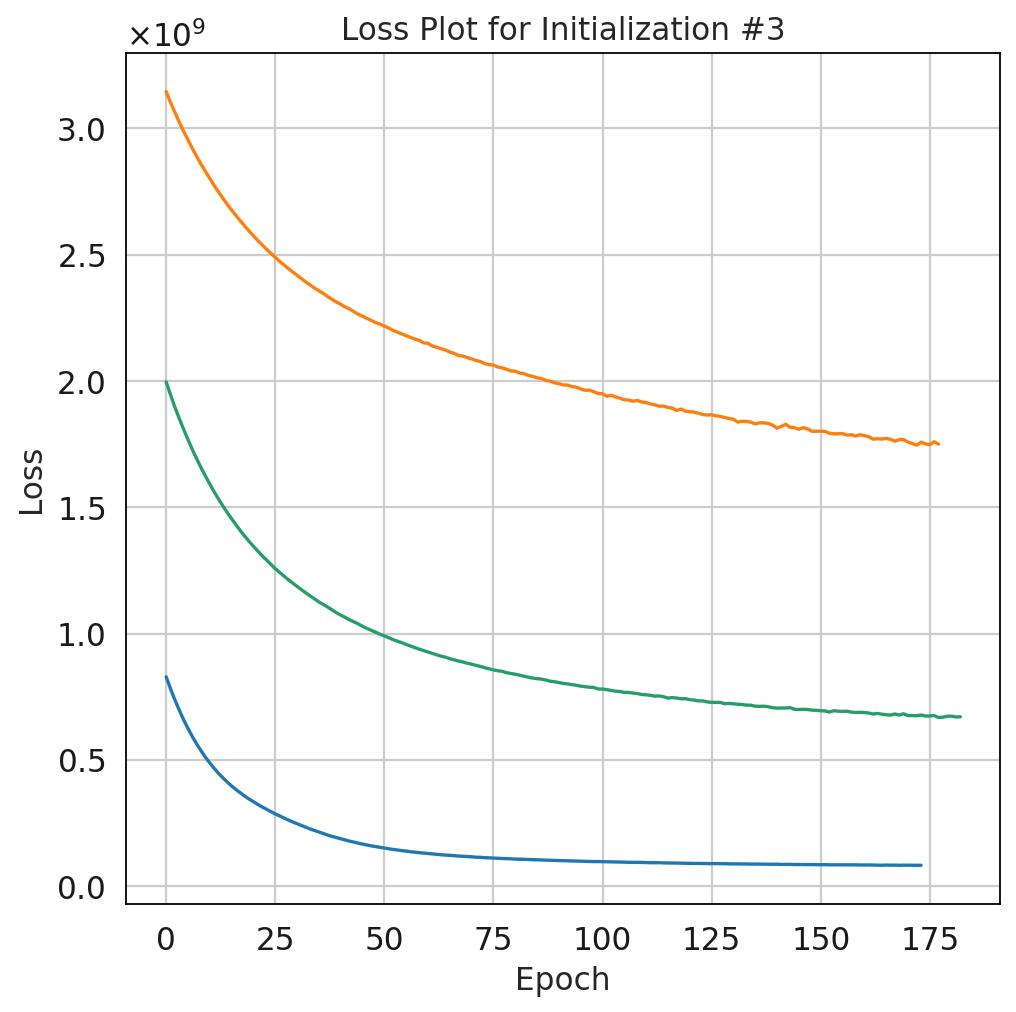

In [10]:
# Train the model 
leaflet_model.train(num_initializations=num_inits)

# Get the best initialization and extract all the latent variables at this initialization
# If you want the latent variables from a different initialization, you can pass the index of that initialization to the get_all_variables() function
leaflet_model.get_all_variables()

In [11]:
leaflet_model.pi, leaflet_model.alpha_pi

(array([0.5179952 , 0.48200482], dtype=float32),
 array(1.4339201, dtype=float32))

Initialization 1 vs Initialization 2: Matched pairs [(0, 1), (1, 0)]
Initialization 1 vs Initialization 3: Matched pairs [(0, 0), (1, 1)]
Initialization 2 vs Initialization 3: Matched pairs [(0, 1), (1, 0)]
Assignment Correlation Report:
Average Pairwise Correlation: 0.9594
Median Pairwise Correlation: 0.9642
Minimum Pairwise Correlation: 0.9411



/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


<Figure size 560x560 with 0 Axes>

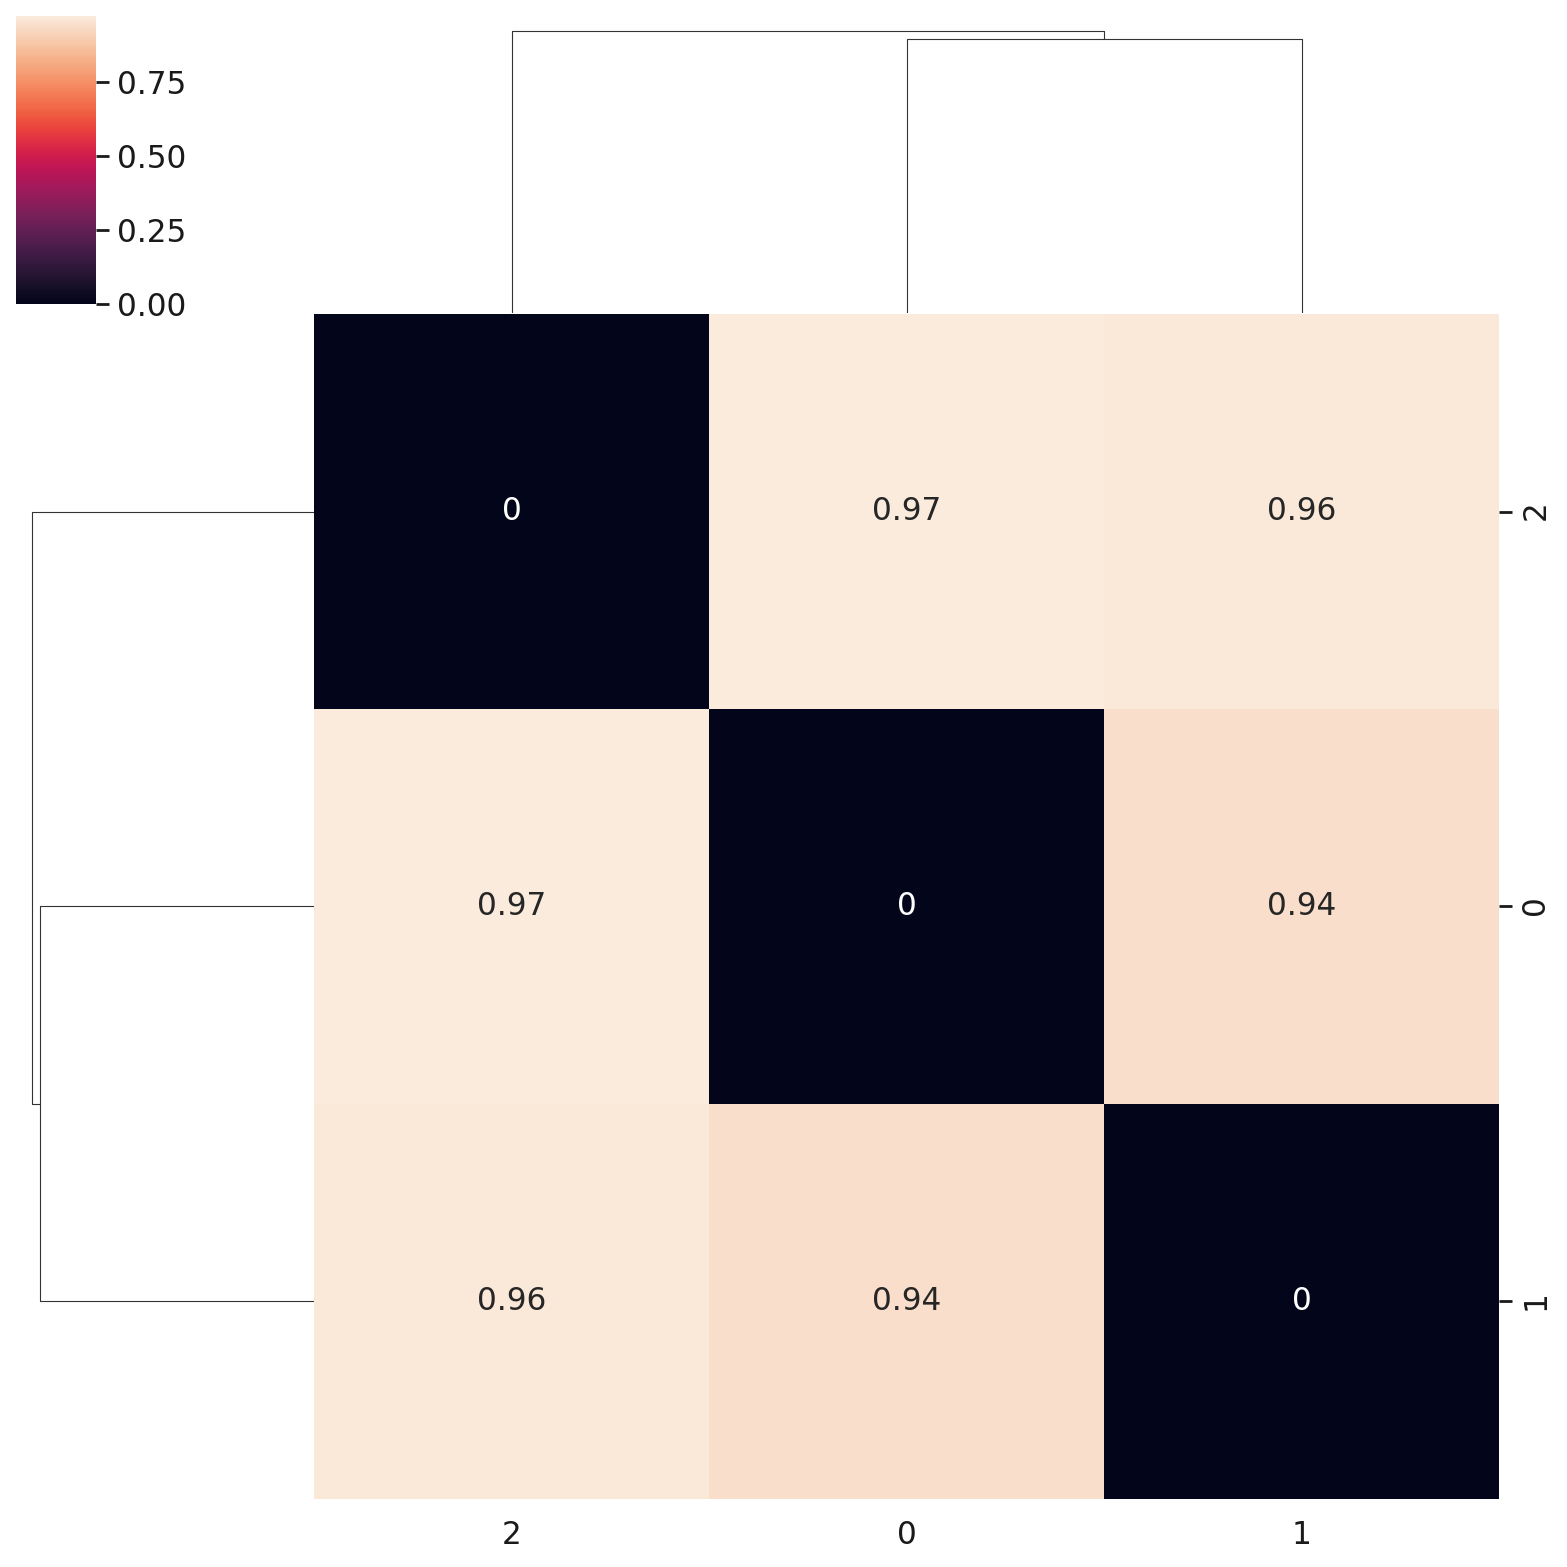

In [12]:
# let's look at the results 
assign_matrices = [result["summary_stats"]["assign"]["mean"] for result in leaflet_model.latent_results]

# Calculate correlations between initializations if more than 2 
if num_inits > 1:
    avg_corr, median_corr, min_corr = utils.calculate_and_plot_correlations(assign_matrices)
else: 
    avg_corr, median_corr, min_corr = None, None, None  # Set default values when there's only one initialization

In [13]:
# Prune K: note this updates all the latent variables in the model to only include estimates for the pruned K
leaflet_model.prune_K()

The K before pruning is 2
The K after pruning is 2
Upating K to 2 in the LeafletFA object.


In [14]:
LEAFLETFA_LATENT_KEY = "X_leafletFA"
adata_input.obsm[LEAFLETFA_LATENT_KEY] = leaflet_model.assign_post # assign_post is the posterior assignment cell-factor activity matrix 
sc.pp.neighbors(adata_input, use_rep=LEAFLETFA_LATENT_KEY, n_neighbors=10)

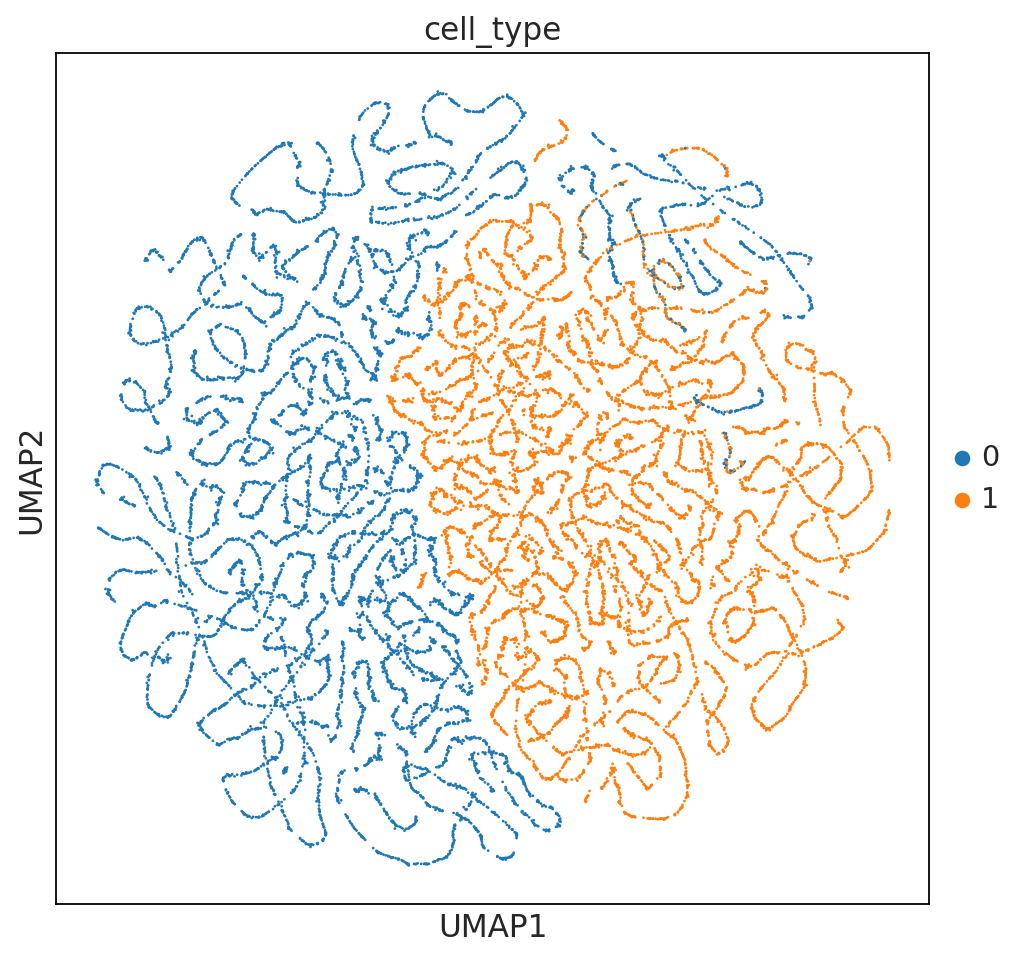

In [15]:
sc.tl.umap(adata_input)
sc.pl.umap(adata_input, color=["cell_type"])

In [16]:
cell_tye_silhouette = ds.calculate_silhouette_score(leaflet_model.assign_post, adata_input.obs.cell_type.values)
print(f"Silhouette score for cell types: {cell_tye_silhouette}")

Silhouette score for cell types: 0.9399294257164001


In [17]:
# extract imputed values 
assign_matrix = leaflet_model.assign_post
psi_matrix = leaflet_model.psi_learned

assign_matrix.shape, psi_matrix.shape

imputed_values = assign_matrix @ psi_matrix
imputed_values.shape # cells by juncs 

# add imputed values to adata_input as a layer called "imputed_PSI"
adata_input.layers["imputed_PSI"] = imputed_values

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.
  warnings.warn(msg, FutureWarning)


In [18]:
adata_input.layers

Layers with keys: Cluster_Counts, Junction_Counts, cell_by_cluster_matrix, cell_by_junction_matrix, imputed_PSI, junc_ratio

In [19]:
# count "sample_label" and "true_label" columns in the adata_input.obs dataframe co-occurence
# what's the min value for difference for positive and negative true_labels 
adata_input.var[adata_input.var["true_label"] == "negative"].difference.max()
adata_input.var[adata_input.var["true_label"] == "positive"].difference.min(), adata_input.var[adata_input.var["true_label"] == "positive"].difference.median(), adata_input.var[adata_input.var["true_label"] == "positive"].difference.max()

(0.00179407, 0.32113445, 0.98594666)

In [20]:
# let's relabel "true_label" column values to "negative" if difference is less than 0.1 and "positive" otherwise
adata_input.var["true_label"] = np.where(adata_input.var["difference"] < 0.1, "negative", "positive")
adata_input.var[adata_input.var["true_label"] == "positive"].difference.min(), adata_input.var[adata_input.var["true_label"] == "positive"].difference.median(), adata_input.var[adata_input.var["true_label"] == "positive"].difference.max()

(0.100081116, 0.34075212, 0.98594666)

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


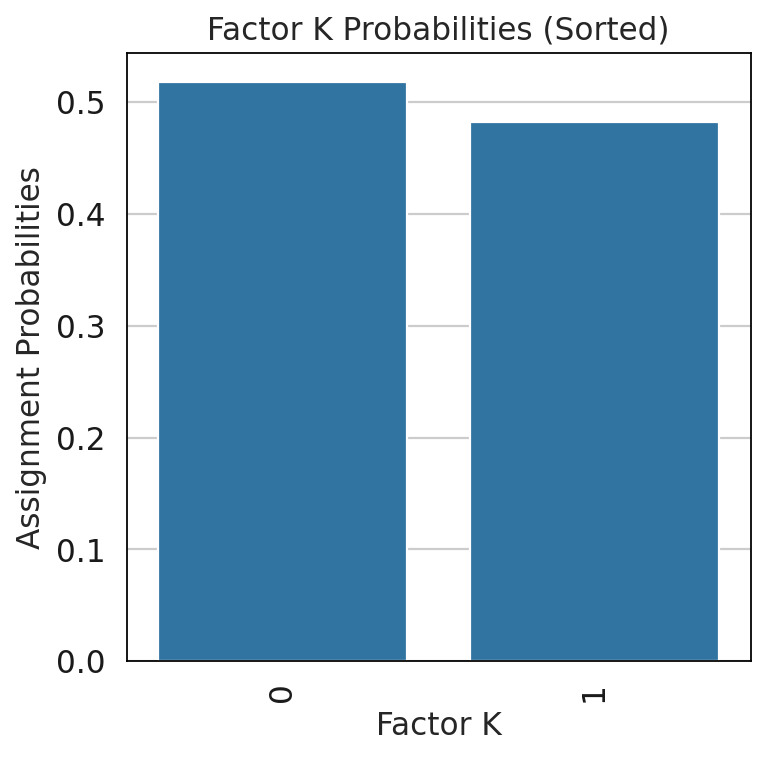

In [21]:
pi_df = pd.DataFrame(leaflet_model.pi, columns=["factor_assignment_probabilities"])
pi_df["factor_K"] = pi_df.index

# Sort by factor_assignment_probabilities in descending order
pi_df = pi_df.sort_values(by="factor_assignment_probabilities", ascending=False)

# Make sorted barplot
plt.figure(figsize=(5, 5))
sns.barplot(x="factor_K", y="factor_assignment_probabilities", data=pi_df, order=pi_df["factor_K"])
plt.title("Factor K Probabilities (Sorted)")
plt.xlabel("Factor K")
plt.ylabel("Assignment Probabilities")
plt.xticks(rotation=90)  # Rotate x-axis labels if many factors
plt.show()

In [22]:
# Let's extract sampled PSI means to calculate imputed difference between groups
# convert leaflet_model.psi_samples to a dataframe rename columns to factor_
factor_psi_df = pd.DataFrame(leaflet_model.psi_learned.T)
factor_psi_df.columns = [f"factor_imputed_psi_{col}" for col in factor_psi_df.columns]

if K == 2:
    factor_psi_df["imputed_diff"] = np.abs(factor_psi_df["factor_imputed_psi_0"] - factor_psi_df["factor_imputed_psi_1"])
if K > 2:
    # Calculate variance across all factors
    factor_psi_df["imputed_diff"] = factor_psi_df.var(axis=1)

In [23]:
factor_psi_df.index = factor_psi_df.index.astype(str)

# Now safe to concatenate
adata_input.var = pd.concat([adata_input.var, factor_psi_df], axis=1)

<Axes: >

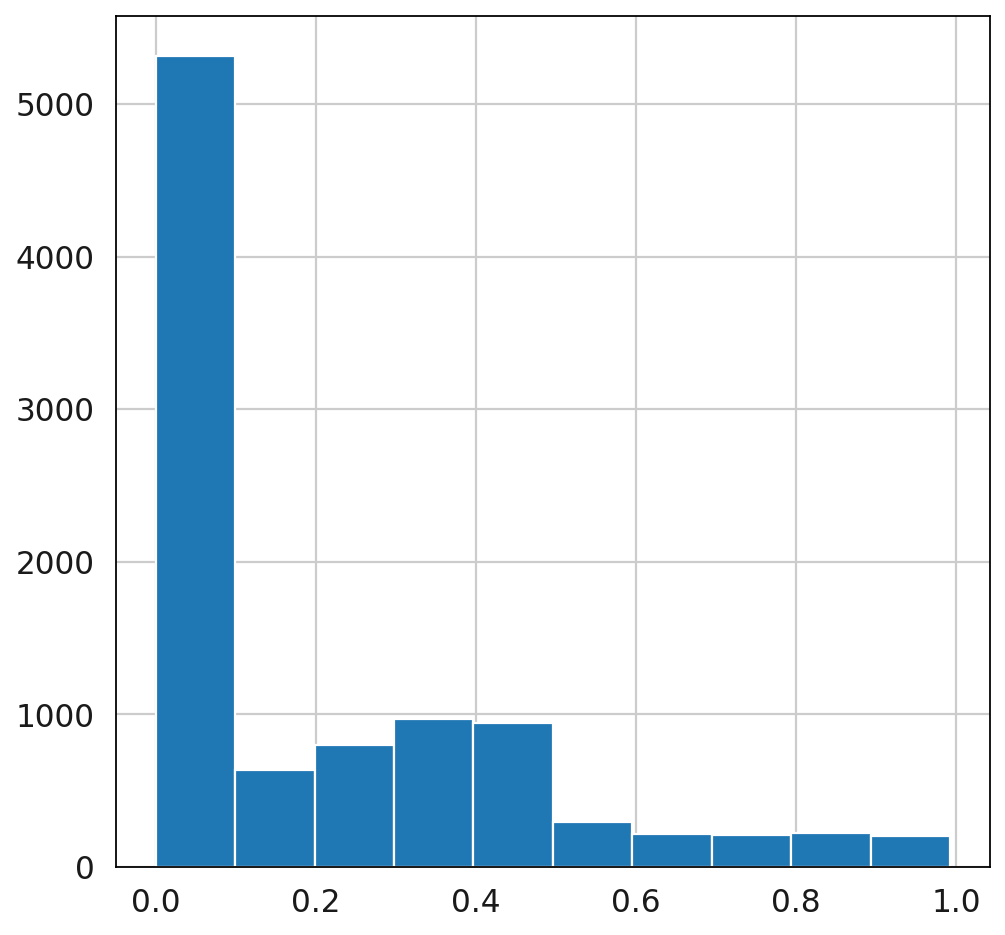

In [24]:
factor_psi_df["imputed_diff"].hist()

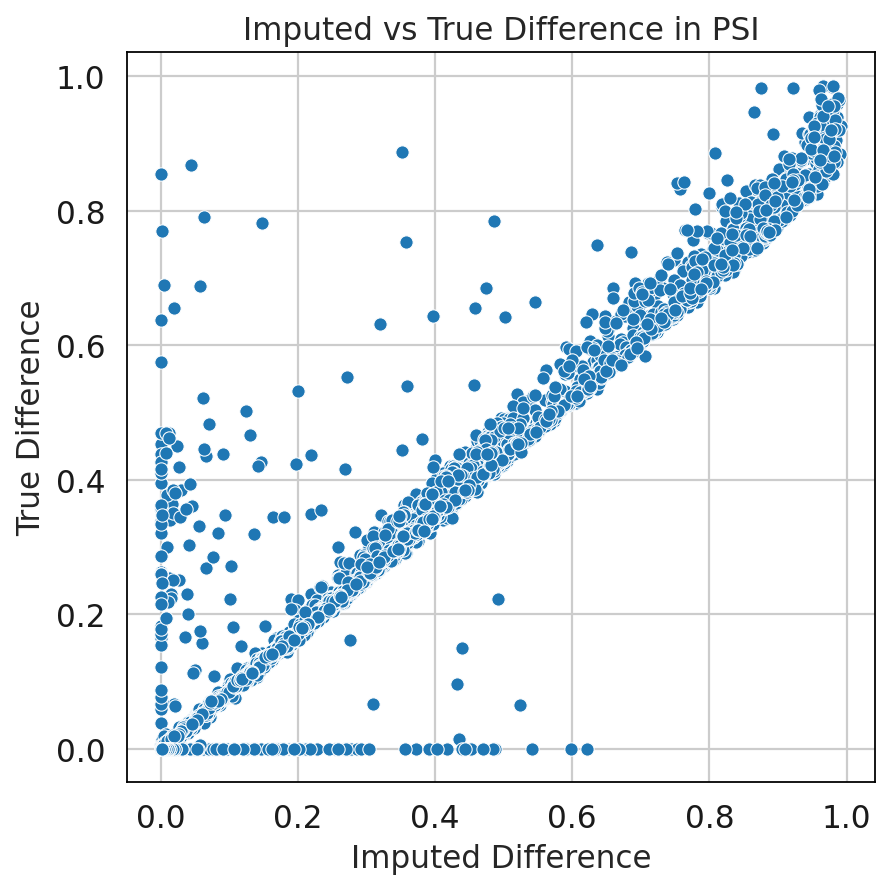

Spearman correlation between imputed and true difference: 0.9128438036007193


In [25]:
# Plot scatterplot correlation between imputed difference and true difference 
plt.figure(figsize=(6, 6))
sns.scatterplot(x="imputed_diff", y="difference", data=adata_input.var)
plt.xlabel("Imputed Difference")
plt.ylabel("True Difference")
plt.title("Imputed vs True Difference in PSI")
plt.show()

# Calculate pearson and spearman correlation
pearson_corr = stats.pearsonr(adata_input.var["imputed_diff"], adata_input.var["difference"])[0]
spearman_corr = stats.spearmanr(adata_input.var["imputed_diff"], adata_input.var["difference"])[0]
print(f"Spearman correlation between imputed and true difference: {spearman_corr}")

In [ ]:
# Calculate AUCROC, PRROC, 

In [ ]:
importlib.reload(ds)

# Define your parameter grid
effect_sizes_to_test = [0.001, 0.01, 0.05, 0.1, 0.25]
fdr_thresholds_to_test = [0.25, 0.1, 0.05, 0.01, 0.001]

# Store results
results_summary = []

# Load junction IDs and psi_samples
top_junctions = adata_input.var["junction_id_index"].values
true_labels = adata_input.var["true_label"].values
psi_samples = leaflet_model.psi_samples

In [ ]:
adata_input.var.sort_values(by="difference")

In [ ]:
x = psi_samples[:, 0, 10]
y = psi_samples[:, 1, 10]

plt.figure(figsize=(6, 4))
plt.hist(x, bins=30, alpha=0.6, label="Factor 0", density=True)
plt.hist(y, bins=30, alpha=0.6, label="Factor 1", density=True)
plt.xlabel("PSI")
plt.ylabel("Density")
plt.title("Histogram of PSI Samples for Junction 10")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Step 1: Compute effect sizes
top_fact_juncs = []
effect_size = 0.1
for j in tqdm(top_junctions, desc="Computing effect sizes"):
    results_dict = ds.compute_psi_effect_size(
        psi_samples, factor_idx=0, junction_idx=j, min_effect_size=effect_size
    )
    top_fact_juncs.append(results_dict)
top_fact_juncs_df = pd.DataFrame(top_fact_juncs)
top_fact_juncs_df

In [ ]:
top_fact_juncs_df["effect_size"].hist()

In [ ]:
for effect_size in effect_sizes_to_test:
    for fdr_threshold in fdr_thresholds_to_test:
        print(f"Running effect_size={effect_size}, fdr_threshold={fdr_threshold}")
        
        # Step 1: Compute effect sizes
        top_fact_juncs = []
        for j in tqdm(top_junctions, desc="Computing effect sizes"):
            results_dict = ds.compute_psi_effect_size(
                psi_samples, factor_idx=0, junction_idx=j, min_effect_size=effect_size
            )
            top_fact_juncs.append(results_dict)
        top_fact_juncs_df = pd.DataFrame(top_fact_juncs)
        
        # Step 2: Compute significance
        top_fact_juncs_df_SIG = ds.compute_junctions_significance_psi(
            top_fact_juncs_df, 
            fdr_threshold=fdr_threshold, 
            min_effect_size=effect_size
        )
        top_fact_juncs_df_SIG["true_labels"] = true_labels

        # Step 3: Confusion matrix
        confusion = pd.crosstab(
            top_fact_juncs_df_SIG["true_labels"],
            top_fact_juncs_df_SIG["significant"],
            rownames=["True"],
            colnames=["Predicted"],
            dropna=False
        )

        # Fill missing entries to avoid KeyErrors
        confusion = confusion.reindex(index=["positive", "negative"], columns=[True, False], fill_value=0)

        # Step 4: Extract metrics
        tp = confusion.loc["positive", True]
        fn = confusion.loc["positive", False]
        fp = confusion.loc["negative", True]
        tn = confusion.loc["negative", False]

        total_positives = tp + fn
        total_discoveries = tp + fp

        observed_fdr = fp / total_discoveries if total_discoveries > 0 else np.nan
        power = tp / total_positives if total_positives > 0 else np.nan
        precision = tp / total_discoveries if total_discoveries > 0 else np.nan
        f1_score = 2 * precision * power / (precision + power) if (precision + power) > 0 else np.nan
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

        results_summary.append({
            "effect_size": effect_size,
            "fdr_threshold": fdr_threshold,
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "TN": tn,
            "FDR": observed_fdr,
            "Power": power,
            "Precision": precision,
            "F1_score": f1_score,
            "Specificity": specificity
        })

# Convert to DataFrame for display
summary_df = pd.DataFrame(results_summary)
print(summary_df)

In [ ]:
# Pivot the DataFrame for heatmap input
heatmap_data = summary_df.pivot(index="effect_size", columns="fdr_threshold", values="Power")

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="viridis")
plt.title("Power Across Effect Size and FDR Threshold")
plt.xlabel("FDR Threshold")
plt.ylabel("Min Effect Size")
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(8, 6))
for fdr in sorted(summary_df["fdr_threshold"].unique(), reverse=True):
    subset = summary_df[summary_df["fdr_threshold"] == fdr]
    plt.plot(subset["effect_size"], subset["Power"], marker="o", label=f"FDR={fdr}")

plt.xlabel("Min Effect Size")
plt.ylabel("Power")
plt.title("Power vs. Effect Size at Different FDR Thresholds")
plt.legend(title="FDR Threshold")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(8, 6))
for fdr in sorted(summary_df["fdr_threshold"].unique(), reverse=True):
    subset = summary_df[summary_df["fdr_threshold"] == fdr]
    plt.plot(subset["Power"], subset["Precision"], marker="o", label=f"FDR={fdr}")

plt.xlabel("Recall (Power)")
plt.ylabel("Precision")
plt.title("Precision vs. Recall at Different FDR Thresholds")
plt.legend(title="FDR Threshold")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot table to visualize FP counts
fp_pivot = summary_df.pivot(index="effect_size", columns="fdr_threshold", values="FP")

plt.figure(figsize=(10, 6))
sns.heatmap(fp_pivot, annot=True, fmt="d", cmap="Reds")
plt.title("False Positives Across Effect Size and FDR Threshold")
plt.xlabel("FDR Threshold")
plt.ylabel("Min Effect Size")
plt.tight_layout()
plt.show()
